# Tag Alterations Database Analysis

## 1. Import Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
pd.set_option('display.max_colwidth', None)
print("Libraries imported successfully")

Libraries imported successfully


## 2. Connect to Database and Load Data

In [2]:
df = pd.read_pickle("../data/full_2025-05.pkl")

### 2.1. Skip if `pickle` used

In [3]:
conn = sqlite3.connect('../data/tags_alterations_full_2025-10.db')
df = pd.read_sql_query("SELECT * FROM tag_inconsistencies", conn)

print(f"Loaded {len(df)} tag inconsistencies from database")

Loaded 4404430 tag inconsistencies from database


In [4]:
for col in ['old_snap_timestamp', 'old_rev_timestamp', 'new_snap_timestamp', 'new_rev_timestamp', 'min_delta']:
    df[col] = pd.to_datetime(df[col], unit='s', errors='coerce')


In [5]:
df['snap_year'] = df['new_snap_timestamp'].dt.year
df['rev_year'] = df['new_rev_timestamp'].dt.year
df['type'] = df['new_revision'].apply(lambda x: 'Alteration' if pd.notna(x) else 'Deletion')

In [6]:
invalid_snapshots = df[df['old_snap_timestamp'] >= df['new_snap_timestamp']]

print(f"Total inconsistencies: {len(df)}")
print(f"Cases where old_snap_timestamp > new_snap_timestamp: {len(invalid_snapshots)}")
print(f"Valid snapshot ordering: {len(df) - len(invalid_snapshots)} ({100 * (len(df) - len(invalid_snapshots)) / len(df):.2f}%)")

if len(invalid_snapshots) > 0:
    print("\nSample of invalid cases:")
    print(invalid_snapshots[['origin_url', 'tag_name', 'old_snap_timestamp', 'new_snap_timestamp']].head(10))
else:
    print("\n✓ All old_snapshot timestamps are older than their corresponding new_snapshot timestamps")

Total inconsistencies: 4404430
Cases where old_snap_timestamp > new_snap_timestamp: 1
Valid snapshot ordering: 4404429 (100.00%)

Sample of invalid cases:
                                             origin_url          tag_name  \
2354352  https://github.com/cornerstonejs/cornerstone3D  refs/tags/v2.2.3   

         old_snap_timestamp  new_snap_timestamp  
2354352 2024-11-12 18:40:57 2024-11-12 18:40:57  


In [7]:
df = df.drop(columns=['id'])

In [8]:
df['delta'] = np.where(
    (df['new_snapshot_cpt'] - df['old_snapshot_cpt']) < 2,
    0,
    (df['min_delta'] - df['old_snap_timestamp']).dt.days
)

In [9]:
df.sample(5)

,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
857459,https://github.com/cristianizzo/go-ethereum,refs/tags/v1.1.3,swh:1:snp:be1474a6da8c625d9aa5ff0ab9ca7f85f8ebed2f,0,2020-06-07 12:41:33,swh:1:rev:59d25c0c2c9e56cc0f51ff4949bf77a55064fb6d,2015-09-09 16:48:35,swh:1:dir:3403d025cd023a262b4edc2f3cadee8387ab15af,swh:1:snp:fa7a959b983a0b5a45917f40077b01cc2141a553,2,2023-11-12 15:17:22,NaN,NaT,NaN,2023-10-04 16:46:43,2023,NaN,Deletion,1214
2213589,https://github.com/netp4ss/intellij-community,refs/tags/clion/142.1610,swh:1:snp:ad7603853286feb4c93a532e3c236d4b3227c8eb,0,2020-03-25 17:03:27,swh:1:rev:5730237c44629b960dcc253ae46b20d0f2017488,2015-05-04 08:29:27,swh:1:dir:ddfa87cd83bfe97d521ad196a0b29d69118a5dd2,swh:1:snp:4cf748d6586442c27de8adada6b6d3970916e0f9,1,2021-07-11 10:33:45,NaN,NaT,NaN,2020-03-25 17:03:27,2021,NaN,Deletion,0
1766256,https://github.com/jinsihou19/intellij-community,refs/tags/rubymine/140.2273,swh:1:snp:112a6dd17dc79d975278de005126b2e4838e002c,0,2017-03-14 15:00:32,swh:1:rev:f8adbf0531a975a1f99558992b4f646adc6bd7da,2015-02-07 00:53:38,swh:1:dir:2b5016a9a1220b6469cbd1e48d52515700530ad8,swh:1:snp:68b60a4868d2b1581671bf7704cd163397004567,6,2021-07-16 23:31:48,NaN,NaT,NaN,2019-05-02 21:19:58,2021,NaN,Deletion,779
4320152,https://github.com/yuwen41200/php-guide,refs/tags/v2.0,swh:1:snp:dc59031ff020083865648ee81ea394bcab8a672e,5,2016-07-25 19:38:58,swh:1:rev:1203f2f6a269724773eeae454fbf9a1dd55b7e47,2016-06-19 14:29:41,swh:1:dir:cb605d2c5ee1164a013bcaca26df46e4995c767d,swh:1:snp:778032dd4ef17c2ab1d2b4b9ca64a9dc51ef1b17,18,2021-01-21 05:01:14,NaN,NaT,NaN,2020-03-03 13:46:21,2021,NaN,Deletion,1316
3208300,https://github.com/RichardHowells/Dnn.Platform,refs/tags/v7.5.0.605-alpha,swh:1:snp:3a3723356c895d22b792cf85bd81b9080c997ab5,1,2016-02-28 20:54:23,swh:1:rev:fcffa2c85dcc9d17a5764edd0a51b9f67557b03e,2015-02-05 23:05:26,swh:1:dir:33aa5552cdea490649a54e8afdac4aeb87d346e8,swh:1:snp:28cc0e4e8a8923abe57a5de27ba4328b1ec77ad3,10,2020-05-28 13:29:24,NaN,NaT,NaN,2020-01-23 00:40:51,2020,NaN,Deletion,1424


In [10]:
with open('../data/full_2025-05.pkl', 'wb') as f:
    pickle.dump(df, f) 

## 3. Explore the DataFrame

In [11]:
print("DataFrame shape:", df.shape)
df.head()

DataFrame shape: (4404430, 19)


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
0,https://github.com/tmshort/openssl,refs/tags/tag/version/6.102.10.1,swh:1:snp:308c9f69bfc8e473ba5d7e50192de5122a8563df,4,2018-09-23 12:01:43,swh:1:rev:b4c40564384b6801b9160401205c925db564aeda,2016-11-08 19:33:47,swh:1:dir:c277a2ec03621fc6d012f163ebe3066d926d58d3,swh:1:snp:51b2e2cd320ffeef292ab5cc2034a1c794192aa0,7,2020-05-29 11:50:19,NaN,NaT,NaN,2018-10-17 04:23:18,2020,NaN,Deletion,23
1,https://github.com/tmshort/openssl,refs/tags/tag/version/7.102.11.1,swh:1:snp:308c9f69bfc8e473ba5d7e50192de5122a8563df,4,2018-09-23 12:01:43,swh:1:rev:7230b7dcee9a433b09dc22b96e52ff8db774c20b,2017-02-09 19:36:45,swh:1:dir:f6e73992b4c5722911225e263eba71c1f56c9dee,swh:1:snp:51b2e2cd320ffeef292ab5cc2034a1c794192aa0,7,2020-05-29 11:50:19,NaN,NaT,NaN,2018-10-17 04:23:18,2020,NaN,Deletion,23
2,https://github.com/tmshort/openssl,refs/tags/tag/version/7.110.6.1,swh:1:snp:308c9f69bfc8e473ba5d7e50192de5122a8563df,4,2018-09-23 12:01:43,swh:1:rev:4a5bcc39931bde5a886c75bee6bc8b046a101396,2017-07-31 13:54:53,swh:1:dir:53d22913d2363ade5b0d5a3baa301c26eb4666ec,swh:1:snp:51b2e2cd320ffeef292ab5cc2034a1c794192aa0,7,2020-05-29 11:50:19,NaN,NaT,NaN,2018-10-17 04:23:18,2020,NaN,Deletion,23
3,https://github.com/tmshort/openssl,refs/tags/tag/version/7.102.11.2,swh:1:snp:308c9f69bfc8e473ba5d7e50192de5122a8563df,4,2018-09-23 12:01:43,swh:1:rev:16b96b4ec8aaef4a1f238dba5fb268325c68a0de,2017-03-24 00:47:21,swh:1:dir:a2d0eaa612a7297895e504cdb64351554d09c9f8,swh:1:snp:51b2e2cd320ffeef292ab5cc2034a1c794192aa0,7,2020-05-29 11:50:19,NaN,NaT,NaN,2018-10-17 04:23:18,2020,NaN,Deletion,23
4,https://github.com/tmshort/openssl,refs/tags/tag/version/7.111.0.0.18.9,swh:1:snp:308c9f69bfc8e473ba5d7e50192de5122a8563df,4,2018-09-23 12:01:43,swh:1:rev:7585918ec5bb2b7fbcc5f1192e9d1a741625f035,2018-08-27 16:17:50,swh:1:dir:8796a47ffcf518841c72baee1b08c06c87f495d3,swh:1:snp:51b2e2cd320ffeef292ab5cc2034a1c794192aa0,7,2020-05-29 11:50:19,NaN,NaT,NaN,2018-10-17 04:23:18,2020,NaN,Deletion,23


## 4. Queries

In [12]:
tag_deletions = df[df['new_revision'].isnull()]
tag_alterations = df[df['new_revision'].notnull()]

print(f"Tag Alterations: {len(tag_alterations)}")
print(f"Tag Deletions: {len(tag_deletions)}")
print(f"Total: {len(df)}")

Tag Alterations: 183265
Tag Deletions: 4221165
Total: 4404430


In [13]:
# Find origins with most tag inconsistencies
origins_with_most_issues = df.groupby('origin_url').size().sort_values(ascending=False)
print("Top 10 origins with most tag inconsistencies:")
origins_with_most_issues.head(10)

Top 10 origins with most tag inconsistencies:


origin_url
https://github.com/jesley-sun/intellij-community     65529
https://github.com/JetBrains/intellij-community      65001
https://github.com/netp4ss/intellij-community        62292
https://github.com/BorzdeG/intellij-community        56363
https://github.com/mallowigi/intellij-community      54768
https://github.com/apixandru/intellij-community      51401
https://github.com/rememberber/intellij-community    47466
https://github.com/udalov/intellij-community         45236
https://github.com/Linuxgt/intellij-community        41493
https://github.com/ursa-labs/crossbow                39119
dtype: int64

In [14]:
tag_alterations[['origin_url', 'tag_name', 'old_snapshot', 'new_snapshot', 'old_snap_timestamp', 'new_snap_timestamp', 'old_rev_timestamp', 'new_rev_timestamp', 'type']].head()

,origin_url,tag_name,old_snapshot,new_snapshot,old_snap_timestamp,new_snap_timestamp,old_rev_timestamp,new_rev_timestamp,type
205,https://github.com/OluTech/magento,refs/tags/1.0.0,swh:1:snp:03661562a9e3f916804f45566494bd19d0dba30e,swh:1:snp:5a5c1fef7cfc27b625c0a169de30aecf4a27a7be,2023-08-11 02:46:54,2023-10-04 07:48:48,2023-05-12 16:33:43,2023-06-05 14:05:56,Alteration
206,https://github.com/OluTech/magento,refs/tags/1.0.1,swh:1:snp:1f9f5872636515e5221e75066d79c5b6e0c6b98a,swh:1:snp:c02e44d5eb3a1928eb624556e9f295e72c0fcefe,2024-02-06 03:22:13,2024-02-12 00:53:09,2024-02-02 09:58:44,2024-02-07 15:31:53,Alteration
207,https://github.com/arc-archive/arc-headers,refs/tags/0.1.0,swh:1:snp:d9fc6de11a32b2b264da7ee4285f5822470eafc5,swh:1:snp:61fc8272b0d5be5bc0af1098e0e470fc2e8c72f7,2021-06-18 11:29:14,2022-06-13 13:51:42,2017-07-05 15:00:02,2020-10-04 07:32:28,Alteration
208,https://github.com/arc-archive/arc-headers,refs/tags/0.1.1,swh:1:snp:d9fc6de11a32b2b264da7ee4285f5822470eafc5,swh:1:snp:61fc8272b0d5be5bc0af1098e0e470fc2e8c72f7,2021-06-18 11:29:14,2022-06-13 13:51:42,2017-07-05 15:12:57,2020-10-04 22:47:03,Alteration
217,https://salsa.debian.org/talau/ns2.git,refs/tags/debian/2.35+dfsg-2,swh:1:snp:fadce3797e316f27d162ab7642f95db706fc62e3,swh:1:snp:f950dc43b3ce52380637c12d6f8503c481442f97,2024-04-25 03:23:26,2025-01-26 16:05:52,2022-11-22 18:33:24,2024-12-09 15:12:09,Alteration


In [15]:
github = df[df['origin_url'].str.contains(r'^https?://[^/]*github\.com', regex=True, na=False)]
gitlab = df[df['origin_url'].str.contains(r'^https?://[^/]*gitlab\.', regex=True, na=False)]
android = df[df['origin_url'].str.contains(r'^https?://android\.googlesource\.com', regex=True, na=False)]
bitbucket = df[df['origin_url'].str.contains(r'^https?://[^/]*bitbucket\.', regex=True, na=False)]
codeberg = df[df['origin_url'].str.contains(r'^https?://[^/]*codeberg\.', regex=True, na=False)]
sourcehut = df[df['origin_url'].str.contains(r'^https?://[^/]*git\.sr\.ht', regex=True, na=False)]
print(f"Amount of inconsistencies in GitHub: {len(github)}")
print(f"Amount of inconsistencies in GitLab: {len(gitlab)}")
print(f"Amount of inconsistencies in Android: {len(android)}")
print(f"Amount of inconsistencies in BitBucket: {len(bitbucket)}")
print(f"Amount of inconsistencies in Codeberg: {len(codeberg)}")
print(f"Amount of inconsistencies in SourceHut: {len(sourcehut)}")

Amount of inconsistencies in GitHub: 4138082
Amount of inconsistencies in GitLab: 175271
Amount of inconsistencies in Android: 70
Amount of inconsistencies in BitBucket: 4159
Amount of inconsistencies in Codeberg: 196
Amount of inconsistencies in SourceHut: 52


In [16]:
github_with_most_issues = github.groupby('origin_url').size().sort_values(ascending=False)
gitlab_with_most_issues = gitlab.groupby('origin_url').size().sort_values(ascending=False)
android_with_most_issues = android.groupby('origin_url').size().sort_values(ascending=False)
bitbucket_with_most_issues = bitbucket.groupby('origin_url').size().sort_values(ascending=False)
codeberg_with_most_issues = codeberg.groupby('origin_url').size().sort_values(ascending=False)
print(f"GitHub most inconsistencies:\n", github_with_most_issues.head(2))
print(f"Gitlab most inconsistencies:\n", gitlab_with_most_issues.head(2))
print(f"Android most inconsistencies:\n", android_with_most_issues.head(2))
print(f"Bitbucket most inconsistencies:\n", bitbucket_with_most_issues.head(2))
print(f"Codeberg most inconsistencies:\n", codeberg_with_most_issues.head(2))

GitHub most inconsistencies:
 origin_url
https://github.com/jesley-sun/intellij-community    65529
https://github.com/JetBrains/intellij-community     65001
dtype: int64
Gitlab most inconsistencies:
 origin_url
https://gitlab.com/yaneti/kernel-ark.git           6387
https://gitlab.com/johnmeneghini/kernel-ark.git    6076
dtype: int64
Android most inconsistencies:
 origin_url
https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime    67
https://android.googlesource.com/platform/packages/apps/Car/Messenger             1
dtype: int64
Bitbucket most inconsistencies:
 origin_url
https://bitbucket.org/apisnetworks/apnscp.git        960
https://bitbucket.org/mediaclickTR/mediapress.git    174
dtype: int64
Codeberg most inconsistencies:
 origin_url
https://codeberg.org/Codeberg/gitea.git                                  109
https://codeberg.org/ungoogled-software/ungoogled-chromium-debian.git     46
dtype: int64


In [17]:
# Inconsistencies where new_root_dir equals old_root_dir
same_root_dir = df[df['new_root_dir'] == df['old_root_dir']]
print(f"Inconsistencies where new_root_dir = old_root_dir: {len(same_root_dir)}")
same_root_dir.head()

Inconsistencies where new_root_dir = old_root_dir: 76039


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
217,https://salsa.debian.org/talau/ns2.git,refs/tags/debian/2.35+dfsg-2,swh:1:snp:fadce3797e316f27d162ab7642f95db706fc62e3,0,2024-04-25 03:23:26,swh:1:rev:9454586bb4dd917c75fc4275ba3aa16c0af51b3e,2022-11-22 18:33:24,swh:1:dir:e80cf24ef559d23b6f0906225b51e57c52e89079,swh:1:snp:f950dc43b3ce52380637c12d6f8503c481442f97,1,2025-01-26 16:05:52,swh:1:rev:4d200e2992a32a7062885e28f54e559a4854e696,2024-12-09 15:12:09,swh:1:dir:e80cf24ef559d23b6f0906225b51e57c52e89079,2024-04-25 03:23:26,2025,2024.0,Alteration,0
218,https://salsa.debian.org/talau/ns2.git,refs/tags/debian/2.35_RC6-4,swh:1:snp:fadce3797e316f27d162ab7642f95db706fc62e3,0,2024-04-25 03:23:26,swh:1:rev:bc2bf131a922bc396905f7a178deb1db54a67c88,2022-11-22 18:28:29,swh:1:dir:c8652306e03b79dc73d45d9e51acc52e1855f3f6,swh:1:snp:f950dc43b3ce52380637c12d6f8503c481442f97,1,2025-01-26 16:05:52,swh:1:rev:e91fe397e74387ef6aeb76e3831977a8eab1d99e,2024-12-09 15:11:57,swh:1:dir:c8652306e03b79dc73d45d9e51acc52e1855f3f6,2024-04-25 03:23:26,2025,2024.0,Alteration,0
220,https://salsa.debian.org/talau/ns2.git,refs/tags/upstream/2.35+dfsg,swh:1:snp:fadce3797e316f27d162ab7642f95db706fc62e3,0,2024-04-25 03:23:26,swh:1:rev:3e10c41de5669b73b25861ea533247fccdafcd22,2022-11-22 18:32:45,swh:1:dir:a2b8df375870becd75ec1594412a779ac4fb6207,swh:1:snp:f950dc43b3ce52380637c12d6f8503c481442f97,1,2025-01-26 16:05:52,swh:1:rev:ceec5215754dc61b5f9c8cc012cf1be2861c7d58,2024-12-09 15:12:04,swh:1:dir:a2b8df375870becd75ec1594412a779ac4fb6207,2024-04-25 03:23:26,2025,2024.0,Alteration,0
222,https://salsa.debian.org/talau/ns2.git,refs/tags/upstream/2.35_rc9,swh:1:snp:fadce3797e316f27d162ab7642f95db706fc62e3,0,2024-04-25 03:23:26,swh:1:rev:8d74af5cb2be7682700898f09e2ed7a3611921cc,2022-11-22 18:30:21,swh:1:dir:14186b0d926351b6b75fe8291a60c11b62d5979f,swh:1:snp:f950dc43b3ce52380637c12d6f8503c481442f97,1,2025-01-26 16:05:52,swh:1:rev:361e62d67c740175b0aa2e420a37e2e8c9b876df,2024-12-09 15:12:00,swh:1:dir:14186b0d926351b6b75fe8291a60c11b62d5979f,2024-04-25 03:23:26,2025,2024.0,Alteration,0
224,https://salsa.debian.org/talau/ns2.git,refs/tags/debian/2.35+dfsg-1.1,swh:1:snp:fadce3797e316f27d162ab7642f95db706fc62e3,0,2024-04-25 03:23:26,swh:1:rev:6309bbc973a4ca50098ac3490d52af74b51fa0fc,2022-11-22 18:33:21,swh:1:dir:22ad96a016447555f788c62ba151e9ecdca1cf5f,swh:1:snp:f950dc43b3ce52380637c12d6f8503c481442f97,1,2025-01-26 16:05:52,swh:1:rev:2e549535dbf7cc2b280c2486a782ef3cb50af4f2,2024-12-09 15:12:07,swh:1:dir:22ad96a016447555f788c62ba151e9ecdca1cf5f,2024-04-25 03:23:26,2025,2024.0,Alteration,0


### 4.1 Most inconsistent

In [18]:
def sample(df, origin):
    case = df[df['origin_url']==origin]
    count = case[['type']].value_counts()
    print(count)
    return case

In [19]:
sample(df, "https://github.com/jesley-sun/intellij-community").sample(2)

type    
Deletion    65529
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2023612,https://github.com/jesley-sun/intellij-community,refs/tags/rubymine/173.204,swh:1:snp:a8670eb262523ea0abac50bd016a4579620ed7b3,0,2020-04-01 23:09:05,swh:1:rev:e76364769ca175e59425cf7054bcaee5d51c7437,2017-06-14 23:13:11,swh:1:dir:c545b1ed644a95e8042a5023fbb28f7165686466,swh:1:snp:8b4ca577993d125d9fe416429e64bdcf94eab763,3,2025-07-26 14:15:42,NaN,NaT,NaN,2025-07-05 11:21:03,2025,NaN,Deletion,1920
2020533,https://github.com/jesley-sun/intellij-community,refs/tags/cidr/120.165,swh:1:snp:a8670eb262523ea0abac50bd016a4579620ed7b3,0,2020-04-01 23:09:05,swh:1:rev:334d2aa91bbec0b18e6bbc106bf489688db9b896,2012-07-18 20:22:53,swh:1:dir:8dd4183c88be9c84468742fc1bfb06a95c59acdc,swh:1:snp:8b4ca577993d125d9fe416429e64bdcf94eab763,3,2025-07-26 14:15:42,NaN,NaT,NaN,2025-07-05 11:21:03,2025,NaN,Deletion,1920


In [20]:
sample(df, "https://github.com/JetBrains/intellij-community").sample(2)

type      
Deletion      65000
Alteration        1
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
3065371,https://github.com/JetBrains/intellij-community,refs/tags/appcode/163.7535,swh:1:snp:0a71b938b8af8a089ff2c0efc14f4e7deb624c85,13,2017-05-03 16:09:19,swh:1:rev:5183d6678c1c692b8227e87576c68995c4e63daa,2016-11-03 08:06:10,swh:1:dir:9e1a726ecbfd82f4d532fe7639494e75cb6e3785,swh:1:snp:513714d5db4bb3e77ed7c182c8aebf2d048b84de,19,2020-11-03 18:16:27,NaN,NaT,NaN,2018-10-13 15:58:55,2020,NaN,Deletion,527
3054971,https://github.com/JetBrains/intellij-community,refs/tags/idea/162.197,swh:1:snp:53ee7c6886e11d45a05486fbe6fd4062d8f78589,5,2016-05-29 15:02:03,swh:1:rev:d70d4346ca0152dac7e67fbdd99971632796f35e,2016-05-14 18:57:21,swh:1:dir:79aa15968d8a1accdd45deb655dc392b2c135e66,swh:1:snp:513714d5db4bb3e77ed7c182c8aebf2d048b84de,19,2020-11-03 18:16:27,NaN,NaT,NaN,2018-10-13 15:58:55,2020,NaN,Deletion,867


In [21]:
sample(df, "https://gitlab.com/yaneti/kernel-ark.git").sample(2)

type    
Deletion    6387
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2658838,https://gitlab.com/yaneti/kernel-ark.git,refs/tags/v4.4.268,swh:1:snp:98b1a9cdc4f29c74c625f17bb59f090f255a5273,0,2022-04-15 20:37:13,swh:1:rev:47127fcd287c91397d11bcf697d12c79169528f2,2021-04-28 10:05:48,swh:1:dir:c820e95113997d03057f869abe0c39b9d549c9c4,swh:1:snp:58c0df2c1a5725692a927925ce9c1de4a7b5b388,3,2025-01-27 23:38:45,NaN,NaT,NaN,2025-01-20 11:06:14,2025,NaN,Deletion,1010
2657555,https://gitlab.com/yaneti/kernel-ark.git,refs/tags/v4.8.6,swh:1:snp:98b1a9cdc4f29c74c625f17bb59f090f255a5273,0,2022-04-15 20:37:13,swh:1:rev:5d506f2133aa81e4a65130c148409512c8f51d7c,2016-10-31 11:26:46,swh:1:dir:0a3b5240529989d0810c72bc1bc3c17341cb4c42,swh:1:snp:58c0df2c1a5725692a927925ce9c1de4a7b5b388,3,2025-01-27 23:38:45,NaN,NaT,NaN,2025-01-20 11:06:14,2025,NaN,Deletion,1010


In [22]:
tmp = sample(df, "https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime")
tmp[tmp['tag_name'].str.contains("jb21-")]

type      
Alteration    64
Deletion       3
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2283490,https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime,refs/tags/jb21-b2,swh:1:snp:7e9f2b9817a5889fe989006ab6f7245fef27aa8d,0,2023-07-22 15:53:42,swh:1:rev:675f4137cf9fdc436edbfb0457aa6fa0b3cc445a,2023-04-14 22:40:30,swh:1:dir:5c44e503bdf9be26c5658947f1b930f57cd1aaa7,swh:1:snp:37a5f4d2cad72224f261563ee01fb89601fa3b42,2,2024-07-25 17:47:54,swh:1:rev:b3c1036696d0c8862acec256e4bca4dad0393003,2023-02-24 13:11:20,swh:1:dir:68aac8087c9e008f956c5fb02be8a2a6d75b1011,2023-11-08 03:17:47,2024,2023.0,Alteration,108
2283511,https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime,refs/tags/jb21-b3,swh:1:snp:7e9f2b9817a5889fe989006ab6f7245fef27aa8d,0,2023-07-22 15:53:42,swh:1:rev:e808f12ee47dedb0883436d75eee3f81cf9eb481,2023-03-30 20:30:43,swh:1:dir:d845cae791ad86d50d4b2ca216588515df6e7b1b,swh:1:snp:37a5f4d2cad72224f261563ee01fb89601fa3b42,2,2024-07-25 17:47:54,swh:1:rev:9182819b00fc78981ced96c1ba21b6645896385a,2023-03-18 10:26:49,swh:1:dir:96282fe9d860104df4777e6d8568751c66e8c35e,2023-11-08 03:17:47,2024,2023.0,Alteration,108
2283520,https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime,refs/tags/jb21-b1,swh:1:snp:7e9f2b9817a5889fe989006ab6f7245fef27aa8d,0,2023-07-22 15:53:42,swh:1:rev:ab95a18b44e89c0f4c79eb86f9ad105d645f818a,2023-04-07 21:40:43,swh:1:dir:35f12031c00dcb0a6ad761c27c9194f45beb85ee,swh:1:snp:37a5f4d2cad72224f261563ee01fb89601fa3b42,2,2024-07-25 17:47:54,swh:1:rev:f1dddd140232e257b9a67cf086f7551b65bf9a1e,2023-02-14 22:50:07,swh:1:dir:bde61eb6bb9baf8f36469a513ff18ba0dc7ad21b,2023-11-08 03:17:47,2024,2023.0,Alteration,108


In [23]:
sample(df, "https://bitbucket.org/apisnetworks/apnscp.git").sample(2)

type      
Deletion      954
Alteration      6
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
1796209,https://bitbucket.org/apisnetworks/apnscp.git,refs/tags/v3.0.19,swh:1:snp:c80032f35506d7f0d58505932e977458f3ecd1a7,0,2019-10-07 18:13:10,swh:1:rev:ed433de6f9e7d1deb518d53e95082f862a315533,2019-02-23 17:19:32,swh:1:dir:9c31a8557a02c07ac1abe0b4005b904892075834,swh:1:snp:7521923b7ce5d445c2f54e108698e60284084385,30,2024-02-25 11:00:26,NaN,NaT,NaN,2024-01-15 17:03:39,2024,NaN,Deletion,1560
1795615,https://bitbucket.org/apisnetworks/apnscp.git,refs/tags/v3.1.44.1,swh:1:snp:2ceedfb13ce020db33363d9fdb0296e9550d5403,37,2024-05-03 02:41:30,swh:1:rev:6ca75f572d44d86d54f7ddd576f76d940005bbfb,2020-07-03 14:46:14,swh:1:dir:ed6e625ddedbe66ed7e1987fdf7569d854db0546,swh:1:snp:1f34e68ccd44b6b2598751a390de36beb725b84f,40,2024-05-24 01:04:04,NaN,NaT,NaN,2024-05-20 23:54:13,2024,NaN,Deletion,17


### 4.2 Time between alterations

#### 4.2.1 Maximum

In [24]:
max = df['delta'].max()
max_incon = df[df['delta']==max]
print(f"Max time taken to produce an inconsistency: {max} days\nAmount of inconsistencies: {len(max_incon)}")
max_incon.head()

Max time taken to produce an inconsistency: 3466 days
Amount of inconsistencies: 1


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
494804,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-2.8.0,swh:1:snp:1b0919feb00c04b980bad18cb22a7e4e41f25eba,1,2016-02-28 08:02:44,swh:1:rev:08c1c42663126d9d52ab5a8579c09fa5a96544f9,2014-08-26 15:04:49,swh:1:dir:26d4999c9d36c5e921312a6c8b5a1370ecf67dd5,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,3466


In [25]:
max_alter = tag_alterations['delta'].max()
max_alter_df = tag_alterations[tag_alterations['delta']==max_alter]
print(len(max_alter_df))
print(max_alter)
max_alter_df

12
3273


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
981461,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.4.4,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:3b3e4fb7b4b41dd6e27c5e8a17235e1cfe66cc32,2015-09-14 14:14:10,swh:1:dir:af9740989efe83ebc86c7f4433a12c3a105e7098,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:3583fdc89bf81d4dc642ad9cfc3c2ef3cb2945b0,2015-09-14 14:14:10,swh:1:dir:eeceef672bc3098208a137bdfa0b5b5d5e70f2cd,2025-09-11 00:12:05,2025,2015.0,Alteration,3273
981462,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.5.17,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:315a02f71f0d3cd1ab9c97dac120a5615794fb75,2016-06-03 17:42:50,swh:1:dir:6193810f7562a81f66b0c1c70b26e262ee940e24,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:4e1bca57499fce105808635c1a4f4cb63df2b74f,2016-06-03 17:42:50,swh:1:dir:d4277ed956dad717fe15b1d5f483c8d68700e688,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981467,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.5.14,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:41d35b9a64db9e4035b30587f315b507169a8fcb,2016-05-06 01:40:00,swh:1:dir:876a3c179df4c1109318eb51f8fbbf02b3cbb9ac,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:46bbfe47f3a577611cd170f921e5640abce9006c,2016-05-06 01:40:00,swh:1:dir:b6e778e82016368a0d41d23761220af1cd975a7c,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981474,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.6.2,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:7086591ee54cfc3e9af5eff9180471697be4a01f,2016-06-28 23:22:30,swh:1:dir:ae46a06f3cd47c4227690de5b292d97713e9e8c0,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:2754c1f07ad7f7b58ceb374b0f5911b3ad69f17e,2016-06-28 23:22:30,swh:1:dir:073fe0e451aee85bc96a86652cfc9928ccde5d3c,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981477,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.4.1,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:9882fd175cb77b60d4c9d2fde74334cf86c009ee,2015-07-02 19:20:23,swh:1:dir:21c5dffcb51d89b626762dab05beee391eaa73e8,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:0dd7ea9c55fd90209cefcbcbce1635728f93adc9,2015-07-02 19:20:23,swh:1:dir:0dd6b73013811a685e61ace16f21beda1ea64c10,2025-09-11 00:12:05,2025,2015.0,Alteration,3273
981490,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.6.7,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:191c7829051e7e47e482c5eacc63866fc41bc84e,2016-09-15 19:24:04,swh:1:dir:6c9de262b92c689ca1dc4131497de3b728976540,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:1a7ce05faea922529b34ed0ca69f4b5c5d0bd3bc,2016-09-15 19:24:04,swh:1:dir:d40fe3f1a5e92f65532d3f39d71c3a7b57a0ac6a,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981491,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.4.6,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:383f779c7b6afc8f18d9e976a86b8391bdfd0780,2015-09-18 21:03:57,swh:1:dir:02c8479d44dab3fef96b774e95a5d52a98c33f84,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:f8c300330fc193961c11d073afe24a9d228b7523,2015-09-18 21:03:57,swh:1:dir:3a466c4f709faa6a55753f0110c577628f47e2c7,2025-09-11 00:12:05,2025,2015.0,Alteration,3273
981495,https://github.com/easydigitaldownloads/easy-digital-downloads

In [38]:
max_alter_df[['old_root_dir', 'new_root_dir']]

,old_root_dir,new_root_dir
981461,swh:1:dir:af9740989efe83ebc86c7f4433a12c3a105e7098,swh:1:dir:eeceef672bc3098208a137bdfa0b5b5d5e70f2cd
981462,swh:1:dir:6193810f7562a81f66b0c1c70b26e262ee940e24,swh:1:dir:d4277ed956dad717fe15b1d5f483c8d68700e688
981467,swh:1:dir:876a3c179df4c1109318eb51f8fbbf02b3cbb9ac,swh:1:dir:b6e778e82016368a0d41d23761220af1cd975a7c
981474,swh:1:dir:ae46a06f3cd47c4227690de5b292d97713e9e8c0,swh:1:dir:073fe0e451aee85bc96a86652cfc9928ccde5d3c
981477,swh:1:dir:21c5dffcb51d89b626762dab05beee391eaa73e8,swh:1:dir:0dd6b73013811a685e61ace16f21beda1ea64c10
981490,swh:1:dir:6c9de262b92c689ca1dc4131497de3b728976540,swh:1:dir:d40fe3f1a5e92f65532d3f39d71c3a7b57a0ac6a
981491,swh:1:dir:02c8479d44dab3fef96b774e95a5d52a98c33f84,swh:1:dir:3a466c4f709faa6a55753f0110c577628f47e2c7
981495,swh:1:dir:1cec827815f9a61a283bddb1700c78bd084a203b,swh:1:dir:a139eaff7e9abce8ed26302e43dd1a89d6bfa17b
981499,swh:1:dir:4cc0618b0310330cfa685621f201f12c08532191,swh:1:dir:efa59e46854bfdf4571e4a51fb878ff560bc58d0
981500,swh:1:dir:3a32d8200e06e0f20acb3bcb84a97468ddd4dc8b,swh:1:dir:fbd914028a0ef5faaa4a38c75759505929b2ada7


In [41]:
max_alter_df[['old_root_dir', 'new_root_dir']].to_csv("dirs_to_extract.csv", index=False, header=False)

In [26]:
sample(df, "https://github.com/phax/ph-javacc-maven-plugin").sample(5)

type    
Deletion    15
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
494800,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-4.0.1,swh:1:snp:80d4d0fdeefdd9246e4c8546eedc178ca6c08f54,11,2018-07-16 10:50:59,swh:1:rev:ac095a1f6c490e682d6a8c458b004efeab395439,2018-01-08 13:04:15,swh:1:dir:794ae56ddb8683a9def4a61cb61d5052052fbb28,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,2597
494803,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-4.1.3,swh:1:snp:9e7d5856588609ea2ff672e580658c605d43e3ab,14,2019-05-08 07:20:55,swh:1:rev:6bc1a49cd896b161a785947e8cffc3ae0ceb6419,2019-05-02 11:45:16,swh:1:dir:8d767b6fef3c454047d44f8494e598fd08c53b41,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,2301
494791,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-4.1.5,swh:1:snp:dba75d612563c0b5c6349257ce01e872ff7c4bc8,24,2022-01-12 22:30:30,swh:1:rev:8578132949d2cfd9be916b7b6da8d2cd658a7912,2022-01-10 17:54:02,swh:1:dir:623be7ea2db0ee081b23701e624bddf467ee1a96,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,1321
494805,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-4.0.3,swh:1:snp:80d4d0fdeefdd9246e4c8546eedc178ca6c08f54,11,2018-07-16 10:50:59,swh:1:rev:c3e788a952e854ae06e913b180a8f7397dfeda47,2018-03-09 13:25:03,swh:1:dir:a3bc1c6f206f29749d0e96b0fe796a70d4ba63cf,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,2597
494792,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-4.1.4,swh:1:snp:8d7cd0927e2da2937565bab8f685de9229ffeeb6,18,2021-01-18 22:58:32,swh:1:rev:5b5cf06fa182ee61938b13b5337427955967e92e,2020-05-13 15:56:02,swh:1:dir:589620ee4c91aa7d9b0d6a2dc4c3b401d0630567,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,1680


In [27]:
median = df['delta'].median()
median_incon = df[df['delta']==median]
print(f"Median time taken to produce an inconsistency: {median} days\nAmount of inconsistencies: {len(median_incon)}")
median_incon.head()

Median time taken to produce an inconsistency: 31.0 days
Amount of inconsistencies: 1544


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
6006,https://github.com/Phanx/Grid,refs/tags/5.0.5.1539,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:b49d23520fb9b199524fd1e93f99d27c67039dfb,2012-10-16 07:03:21,swh:1:dir:b57e9bc89ea54e76275f74f6238335c689487e5c,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6007,https://github.com/Phanx/Grid,refs/tags/1.30300.1290,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:54df2511300aad6e3c564e02f08f414a2799d7d6,2010-04-16 05:01:53,swh:1:dir:0ca265b6b26bf4b91cb68af9e717d5669f11dcb9,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6008,https://github.com/Phanx/Grid,refs/tags/5.0.4.1517,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:720cb6daa011a39ec34c8934ee4206d236176680,2012-08-28 09:26:01,swh:1:dir:b841f360a3c17e0fe6842d2f77d616f5074cd15a,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6009,https://github.com/Phanx/Grid,refs/tags/4.3.0.1453,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:b61d6ec418c609ea99fd6fb5f73fd17b67d10575,2011-12-13 00:33:17,swh:1:dir:41bff4739b2de5f10655b994b071962b548fb1ac,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6010,https://github.com/Phanx/Grid,refs/tags/6.0.3.1714-beta,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:2e8964e078aa737b070270d730af1b9ddee79c39,2014-11-14 14:03:01,swh:1:dir:fa0d73065df8130663bf30f44ad461e274d7255f,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31


### 4.3 Time between revision after alteration

In [28]:
tag_alterations['rev_time_diff_days'] = (tag_alterations['new_rev_timestamp'] - tag_alterations['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)

#### 4.3.1 Minimum

In [29]:
min = tag_alterations['rev_time_diff_days'].min()
min_alter = tag_alterations[tag_alterations['rev_time_diff_days']==min]
print(f'Minimum time between revisions after alteration {min} days\nAmount of alterations: {len(min_alter)}')
min_alter.head()

Minimum time between revisions after alteration -9308.671967592592 days
Amount of alterations: 1


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta,rev_time_diff_days
1589598,https://gitlab.com/OldManProgrammer/unix-tree.git,refs/tags/1.1,swh:1:snp:ea5cc879e3005aa565003296184c39841040ac8b,0,2022-03-22 02:20:49,swh:1:rev:77382cd00f7ff307b5511eb52bb43ac9ab45010d,2022-03-21 20:46:43,swh:1:dir:6849849dd4026052cf2be53339e1142575de80fd,swh:1:snp:26a5686cff3cff5cde9262e0e8ba79daaf17b545,1,2022-03-27 08:01:24,swh:1:rev:ec4e95761c0099a24d0ce849162614edf55f05ff,1996-09-25 04:39:05,swh:1:dir:6849849dd4026052cf2be53339e1142575de80fd,2022-03-22 02:20:49,2022,1996.0,Alteration,0,-9308.671968


#### 4.3.2 Maximum

In [30]:
max = tag_alterations['rev_time_diff_days'].max()
max_alter = tag_alterations[tag_alterations['rev_time_diff_days']==max]
print(f'Maximum time between revisions after alteration {max} days\nAmount of alterations: {len(max_alter)}')
max_alter.head()

Maximum time between revisions after alteration 5109.004930555556 days
Amount of alterations: 1


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta,rev_time_diff_days
2569193,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-2,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:ce10d50c6880282a5b23ddee242d5e669dc6538d,2008-01-11 05:00:54,swh:1:dir:16a6deb2858a4580a872a5b41f402cb83b3b6b52,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:8a54bb1806abe4a0d54ab11995ccdcafa2abd10b,2022-01-06 05:08:00,swh:1:dir:bcd8ff8fbd678c8a1e8cdb25b587f8fe36ff2a88,2021-08-13 10:48:17,2024,2022.0,Alteration,552,5109.004931


In [31]:
sample(df, "https://salsa.debian.org/java-team/libjmac-java.git").sample(5)

type      
Alteration    5
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2569193,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-2,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:ce10d50c6880282a5b23ddee242d5e669dc6538d,2008-01-11 05:00:54,swh:1:dir:16a6deb2858a4580a872a5b41f402cb83b3b6b52,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:8a54bb1806abe4a0d54ab11995ccdcafa2abd10b,2022-01-06 05:08:00,swh:1:dir:bcd8ff8fbd678c8a1e8cdb25b587f8fe36ff2a88,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569194,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-3,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:51d368c02bd93c6cb31322146fb0ef7d3f58c922,2009-01-14 21:49:27,swh:1:dir:ccc5419cf8714939f9ac4c653b55442fa9da38aa,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:80910f835628820cb38ce7b89ad3333112a589cd,2022-01-06 05:08:00,swh:1:dir:4316114d0dd7b808daaf780774966dd59776469f,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569192,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-5,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:c4a43b19a55d694458c4e0315b6cc93006c427cf,2009-02-15 21:30:26,swh:1:dir:79633af1d024f40a5760ad3ff3a0bdf79881f130,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:984bb86f8c2fe475f1cafca9a03fac56bd740995,2022-01-06 05:08:01,swh:1:dir:797bc2217f364569d89ff64b00dbb836460db441,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569190,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-6,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:0b1d90ecfe092e7f4dd13afbfa9781d934d24e92,2011-08-11 12:35:58,swh:1:dir:a530358c6fcae671eeab12f4d1e8c5d1010e5092,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:ab223b32e2191f3ef1e2860e4f0ef6b162082294,2022-01-06 05:08:01,swh:1:dir:fe180e132c3aa2aad6083c263fd5dabd10f86e11,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569191,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-4,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:8455a4bc7aa068b600918b61e9b17f2724519123,2009-01-15 18:28:26,swh:1:dir:e22d014dba8b013003f84cef354afea7f84f87bd,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:d425762ac52f1dcea0253643f741c8bcfe6374c7,2022-01-06 05:08:01,swh:1:dir:59285ae98838b663cb065f4b9d52a67452bbb0b0,2021-08-13 10:48:17,2024,2022.0,Alteration,552


## 5. Figures

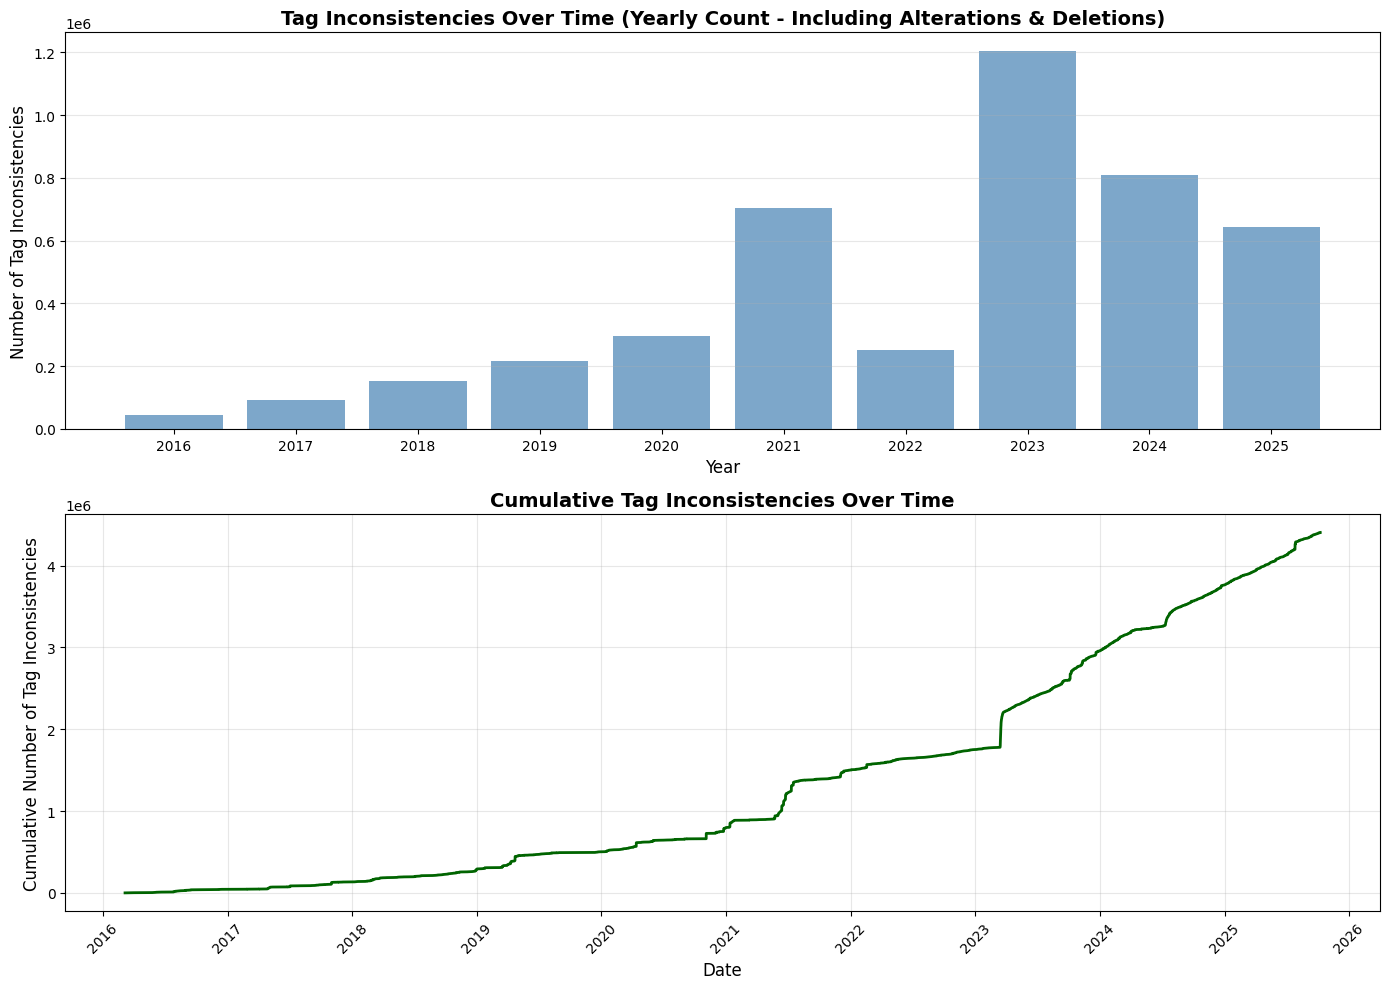

Total tag inconsistencies plotted: 4404430
  - Tag Alterations: 183265
  - Tag Deletions: 4221165
Date range: 2016-03-06 04:10:12 to 2025-10-08 14:44:16


In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_sorted = df.sort_values('new_snap_timestamp')
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

df['year'] = df['new_snap_timestamp'].dt.year
inconsistencies_by_year = df.groupby('year').size()

ax1.bar(inconsistencies_by_year.index, inconsistencies_by_year.values, width=0.8, alpha=0.7, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Inconsistencies', fontsize=12)
ax1.set_title('Tag Inconsistencies Over Time (Yearly Count - Including Alterations & Deletions)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(inconsistencies_by_year.index)

ax2.plot(df_sorted['new_snap_timestamp'], 
         df_sorted['cumulative_count'], 
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Inconsistencies', fontsize=12)
ax2.set_title('Cumulative Tag Inconsistencies Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Total tag inconsistencies plotted: {len(df)}")
print(f"  - Tag Alterations: {len(tag_alterations)}")
print(f"  - Tag Deletions: {len(tag_deletions)}")
print(f"Date range: {df['new_snap_timestamp'].min()} to {df['new_snap_timestamp'].max()}")

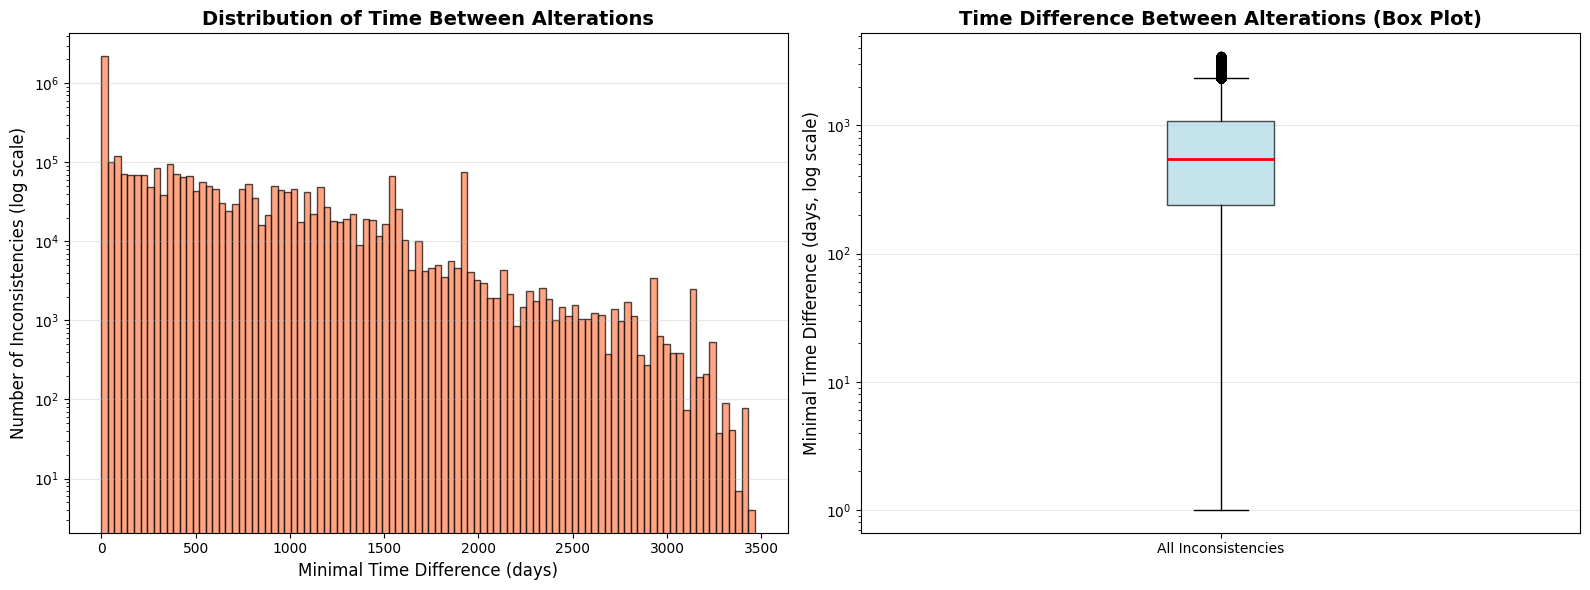

Time difference statistics:
  Mean: 368.19 days
  Median: 31.00 days
  Min: 0.00 days
  Max: 3466.00 days
  Std: 552.51 days


In [33]:
#df['time_diff_days'] = (df['new_snap_timestamp'] - df['old_snap_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_diffs_filtered = df['delta'].dropna()
ax1.hist(time_diffs_filtered, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Minimal Time Difference (days)', fontsize=12)
ax1.set_ylabel('Number of Inconsistencies (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Alterations', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([time_diffs_filtered[time_diffs_filtered > 0]], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Minimal Time Difference (days, log scale)', fontsize=12)
ax2.set_title('Time Difference Between Alterations (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['All Inconsistencies'])

plt.tight_layout()
plt.show()

print(f"Time difference statistics:")
print(f"  Mean: {time_diffs_filtered.mean():.2f} days")
print(f"  Median: {time_diffs_filtered.median():.2f} days")
print(f"  Min: {time_diffs_filtered.min():.2f} days")
print(f"  Max: {time_diffs_filtered.max():.2f} days")
print(f"  Std: {time_diffs_filtered.std():.2f} days")


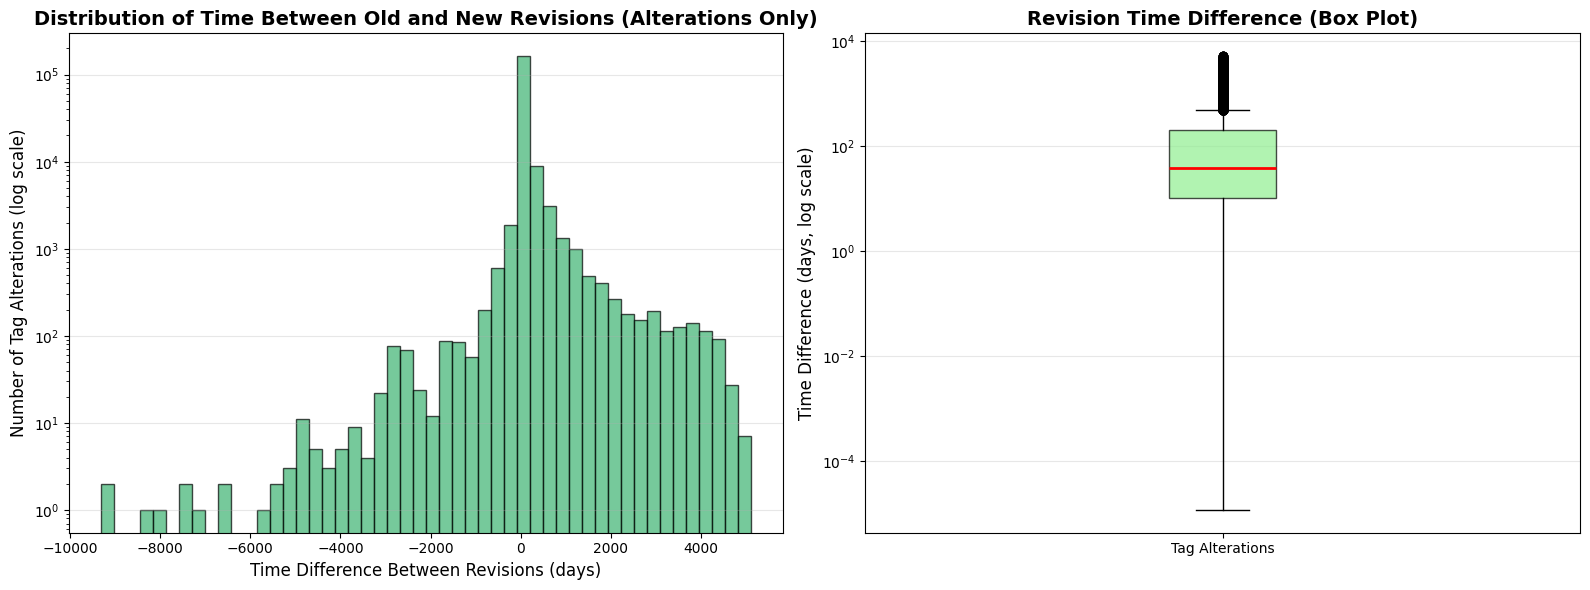

Revision time difference statistics (for 183265 alterations):
  Mean: 70.35 days
  Median: 0.00 days
  Min: -9308.67 days
  Max: 5109.00 days
  Std: 362.01 days
  Negative values (new revision older than old): 11252


In [34]:
tag_alterations['rev_time_diff_days'] = (tag_alterations['new_rev_timestamp'] - tag_alterations['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rev_time_diffs = tag_alterations['rev_time_diff_days'].dropna()
ax1.hist(rev_time_diffs, bins=50, alpha=0.7, color='mediumseagreen', edgecolor='black')
ax1.set_xlabel('Time Difference Between Revisions (days)', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Old and New Revisions (Alterations Only)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_yscale('log')

positive_rev_diffs = rev_time_diffs[rev_time_diffs > 0]
if len(positive_rev_diffs) > 0:
    ax2.boxplot([positive_rev_diffs], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Time Difference (days, log scale)', fontsize=12)
    ax2.set_title('Revision Time Difference (Box Plot)', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(['Tag Alterations'])

plt.tight_layout()
plt.show()

print(f"Revision time difference statistics (for {len(tag_alterations)} alterations):")
print(f"  Mean: {rev_time_diffs.mean():.2f} days")
print(f"  Median: {rev_time_diffs.median():.2f} days")
print(f"  Min: {rev_time_diffs.min():.2f} days")
print(f"  Max: {rev_time_diffs.max():.2f} days")
print(f"  Std: {rev_time_diffs.std():.2f} days")
print(f"  Negative values (new revision older than old): {len(rev_time_diffs[rev_time_diffs < 0])}")

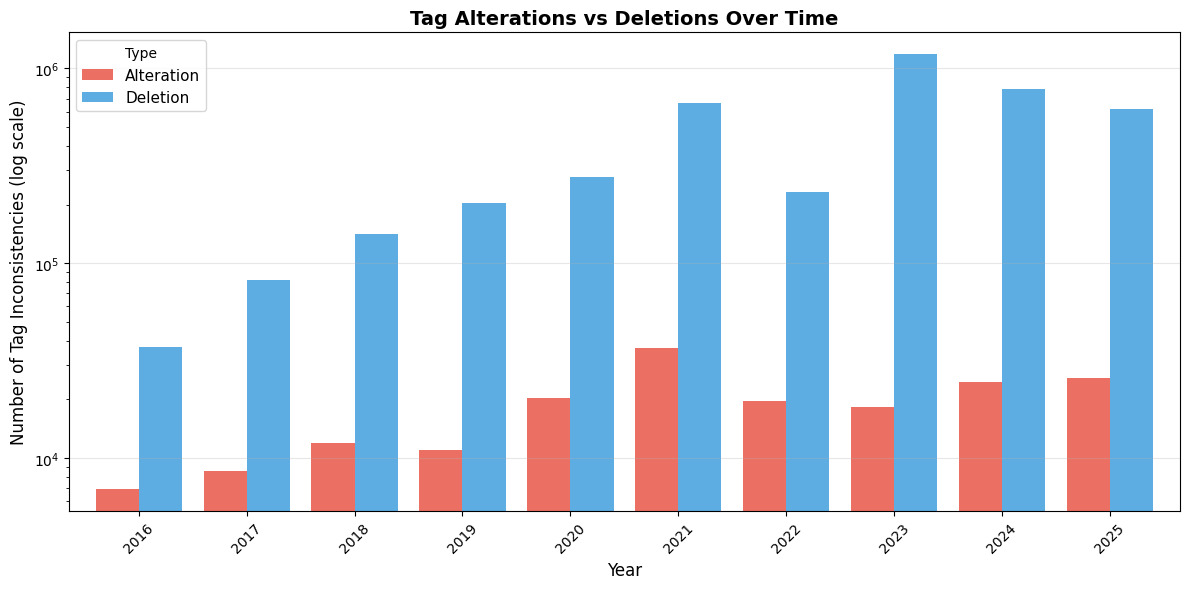


Yearly breakdown:
type  Alteration  Deletion
year                      
2016        6899     37115
2017        8590     81814
2018       11904    140389
2019       11025    204006
2020       20352    275973
2021       36558    666723
2022       19553    230999
2023       18125   1185246
2024       24422    783165
2025       25837    615735

Total Alterations: 183265
Total Deletions: 4221165


In [35]:
inconsistencies_by_year_type = df.groupby(['year', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

inconsistencies_by_year_type.plot(kind='bar', ax=ax, 
                                   color=['#e74c3c', '#3498db'], alpha=0.8, width=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Tag Inconsistencies (log scale)', fontsize=12)
ax.set_title('Tag Alterations vs Deletions Over Time', fontsize=14, fontweight='bold')
ax.legend(title='Type', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')  # Log scale to see alterations better

plt.tight_layout()
plt.show()

print("\nYearly breakdown:")
print(inconsistencies_by_year_type)
print(f"\nTotal Alterations: {inconsistencies_by_year_type['Alteration'].sum()}")
print(f"Total Deletions: {inconsistencies_by_year_type['Deletion'].sum()}")

## Last. Close Database Connection

In [37]:
conn.close()
print("Database connection closed")

Database connection closed
